# Geometric Knowledge Network Demo

This notebook produces a **fully saved, reviewable baseline-vs-hybrid evaluation package** for the current GKN MVP.

All heavy logic remains in `src/`; the notebook orchestrates the run, displays outputs, and saves artifacts locally.

## 1. Setup

Import the project modules, initialize configuration, and set up artifact-saving helpers.

In [1]:
from pathlib import Path
import sys
from collections import Counter
import pandas as pd

sys.path.append(str(Path.cwd().parent / 'src'))

from geometric_knowledge_network.config import GKNConfig
from geometric_knowledge_network.evaluation import evaluate_retrieval, load_query_test_cases
from geometric_knowledge_network.extraction import ConceptExtractor
from geometric_knowledge_network.graph_builder import KnowledgeNetworkBuilder
from geometric_knowledge_network.hybrid_retriever import HybridRetriever
from geometric_knowledge_network.ingest import DocumentIngestor
from geometric_knowledge_network.reporting import ArtifactManager
from geometric_knowledge_network.vector_store import SimpleVectorStore
from geometric_knowledge_network.visualization import draw_subgraph

config = GKNConfig()
artifacts = ArtifactManager(config.artifacts_dir)
run_id = artifacts.timestamp()

def status(message: str):
    print(f'[DONE] {message}')

def preview_results(results, title):
    print(f'\n{title}')
    print('-' * len(title))
    for i, result in enumerate(results, start=1):
        source = getattr(result, 'source', 'vector')
        vector_score = getattr(result, 'vector_score', getattr(result, 'score', 0.0))
        graph_bonus = getattr(result, 'graph_bonus', 0.0)
        final_score = getattr(result, 'final_score', getattr(result, 'score', 0.0))
        preview_text = result.text[:180].replace(chr(10), ' ')
        print(f'{i}. {result.chunk_id} | source={source} | vector={vector_score:.3f} | graph_bonus={graph_bonus:.3f} | final={final_score:.3f}')
        print(f'   {preview_text}...')

def results_to_records(results):
    records = []
    for rank, result in enumerate(results, start=1):
        records.append({
            'rank': rank,
            'chunk_id': result.chunk_id,
            'doc_id': result.doc_id,
            'source': getattr(result, 'source', 'vector'),
            'vector_score': getattr(result, 'vector_score', getattr(result, 'score', 0.0)),
            'graph_bonus': getattr(result, 'graph_bonus', 0.0),
            'final_score': getattr(result, 'final_score', getattr(result, 'score', 0.0)),
            'text_preview': result.text[:200].replace(chr(10), ' '),
        })
    return records

status(f'Setup complete. Run ID: {run_id}')

[DONE] Setup complete. Run ID: 20260613_135746


## 2. Load sample documents

Load the sample corpus and save a document inventory for review.

In [2]:
ingestor = DocumentIngestor()
documents = ingestor.load_text_documents(config.sample_docs_dir)
status(f'Loaded {len(documents)} sample documents from {config.sample_docs_dir}.')

for doc in documents:
    print(f'- {doc.doc_id}: {doc.title}')

document_inventory = pd.DataFrame([
    {
        'doc_id': doc.doc_id,
        'title': doc.title,
        'source_path': doc.source_path,
        'text_hash': doc.text_hash,
    }
    for doc in documents
])
inventory_path = artifacts.save_dataframe(document_inventory, f'document_inventory_{run_id}.csv')
status(f'Saved document inventory to {inventory_path}')

[DONE] Loaded 16 sample documents from C:\Users\minwuu01\GKN\data\sample_docs.
- ai_governance_policy: Ai Governance Policy
- approval_workflow: Approval Workflow
- audit_findings_memo: Audit Findings Memo
- change_management_standard: Change Management Standard
- control_inventory: Control Inventory
- control_testing_procedure: Control Testing Procedure
- documentation_retention_policy: Documentation Retention Policy
- incident_response_procedure: Incident Response Procedure
- issue_remediation_guideline: Issue Remediation Guideline
- model_development_standard: Model Development Standard
- model_monitoring_standard: Model Monitoring Standard
- model_risk_taxonomy: Model Risk Taxonomy
- model_validation_standard: Model Validation Standard
- regulatory_guidance_summary: Regulatory Guidance Summary
- risk_acceptance_procedure: Risk Acceptance Procedure
- validation_evidence_checklist: Validation Evidence Checklist
[DONE] Saved document inventory to C:\Users\minwuu01\GKN\artifacts\report

## 3. Chunk the documents

Create retrieval chunks and save a chunk inventory for inspection.

In [3]:
chunks = ingestor.chunk_documents(documents, config.chunk_size, config.chunk_overlap)
status(f'Created {len(chunks)} chunks.')

for chunk in chunks[:5]:
    preview_text = chunk.text[:160].replace(chr(10), ' ')
    print(f'{chunk.chunk_id} | doc={chunk.doc_id} | chars={len(chunk.text)}')
    print(f'  {preview_text}...')

chunk_inventory = pd.DataFrame([
    {
        'chunk_id': chunk.chunk_id,
        'doc_id': chunk.doc_id,
        'start_idx': chunk.start_idx,
        'end_idx': chunk.end_idx,
        'text_preview': chunk.text[:200].replace(chr(10), ' '),
    }
    for chunk in chunks
])
chunk_path = artifacts.save_dataframe(chunk_inventory, f'chunk_inventory_{run_id}.csv')
status(f'Saved chunk inventory to {chunk_path}')

[DONE] Created 16 chunks.
ai_governance_policy_chunk_0 | doc=ai_governance_policy | chars=428
  AI Governance Policy  All high-impact AI systems must complete validation before approval for production use. Validation evidence must include testing results, ...
approval_workflow_chunk_0 | doc=approval_workflow | chars=378
  Approval Workflow  Production approval requires validation completion, evidence review, and control confirmation. The approval committee must confirm that requi...
audit_findings_memo_chunk_0 | doc=audit_findings_memo | chars=312
  Audit Findings Memo  Audit finding F-12 noted that annual review evidence was incomplete for one production AI system. The finding requires remediation, updated...
change_management_standard_chunk_0 | doc=change_management_standard | chars=387
  Change Management Standard  Any material model change requires impact assessment, updated validation, and refreshed approval evidence. Changes affecting monitor...
control_inventory_chunk_0 | doc=co

## 4. Build the baseline vector retriever

Run a baseline retrieval query and save the returned chunks.

In [4]:
vector_store = SimpleVectorStore()
vector_store.build(chunks)
status('Vector index built successfully.')

query = 'What evidence is required for validation approval?'
baseline_results = vector_store.search(query, top_k=config.top_k)
preview_results(baseline_results, f'Baseline retrieval results for query: {query}')

baseline_path = artifacts.save_json(
    {
        'run_id': run_id,
        'query': query,
        'results': results_to_records(baseline_results),
    },
    f'baseline_main_query_{run_id}.json',
    subdir='results',
)
status(f'Saved baseline retrieval results to {baseline_path}')

[DONE] Vector index built successfully.

Baseline retrieval results for query: What evidence is required for validation approval?
----------------------------------------------------------------------------------------
1. ai_governance_policy_chunk_0 | source=vector | vector=0.407 | graph_bonus=0.000 | final=0.407
   AI Governance Policy  All high-impact AI systems must complete validation before approval for production use. Validation evidence must include testing results, monitoring design, a...
2. approval_workflow_chunk_0 | source=vector | vector=0.404 | graph_bonus=0.000 | final=0.404
   Approval Workflow  Production approval requires validation completion, evidence review, and control confirmation. The approval committee must confirm that required controls are imp...
3. validation_evidence_checklist_chunk_0 | source=vector | vector=0.353 | graph_bonus=0.000 | final=0.353
   Validation Evidence Checklist  Validation approval requires documented testing evidence, monitoring readine

## 5. Build the knowledge network

Construct the graph and save a graph summary.

In [5]:
extractor = ConceptExtractor(config.concept_keywords)
graph = KnowledgeNetworkBuilder(extractor).build(documents, chunks)
status(f'Knowledge network built with {graph.number_of_nodes()} nodes and {graph.number_of_edges()} edges.')

node_type_counts = Counter(graph.nodes[node].get('node_type', 'Unknown') for node in graph.nodes)
for node_type, count in sorted(node_type_counts.items()):
    print(f'- {node_type}: {count}')

graph_summary_path = artifacts.save_graph_summary(graph, f'graph_summary_{run_id}.json')
status(f'Saved graph summary to {graph_summary_path}')

[DONE] Knowledge network built with 95 nodes and 456 edges.
- Chunk: 16
- Concept: 6
- Control: 5
- Document: 16
- Evidence: 7
- Incident: 9
- Requirement: 36
[DONE] Saved graph summary to C:\Users\minwuu01\GKN\artifacts\graph\graph_summary_20260613_135746.json


## 6. Run hybrid retrieval

Run graph-enhanced retrieval and save the returned chunks.

In [6]:
hybrid = HybridRetriever(vector_store, graph)
hybrid_results = hybrid.search(query, top_k=config.top_k, graph_hops=config.graph_hops)
status('Hybrid retrieval completed.')
preview_results(hybrid_results, f'Hybrid retrieval results for query: {query}')

hybrid_path = artifacts.save_json(
    {
        'run_id': run_id,
        'query': query,
        'results': results_to_records(hybrid_results),
    },
    f'hybrid_main_query_{run_id}.json',
    subdir='results',
)
status(f'Saved hybrid retrieval results to {hybrid_path}')

[DONE] Hybrid retrieval completed.

Hybrid retrieval results for query: What evidence is required for validation approval?
--------------------------------------------------------------------------------------
1. validation_evidence_checklist_chunk_0 | source=vector | vector=0.353 | graph_bonus=3.105 | final=3.458
   Validation Evidence Checklist  Validation approval requires documented testing evidence, monitoring readiness evidence, and documented limitations. Evidence packages must include t...
2. approval_workflow_chunk_0 | source=vector | vector=0.404 | graph_bonus=2.968 | final=3.372
   Approval Workflow  Production approval requires validation completion, evidence review, and control confirmation. The approval committee must confirm that required controls are imp...
3. ai_governance_policy_chunk_0 | source=vector | vector=0.407 | graph_bonus=2.833 | final=3.240
   AI Governance Policy  All high-impact AI systems must complete validation before approval for production use. Valida

## 7. Compare baseline and hybrid retrieval

Create a simple side-by-side comparison table and save it as a report.

In [7]:
comparison_rows = []
for label, results in [('baseline', baseline_results), ('hybrid', hybrid_results)]:
    for record in results_to_records(results):
        comparison_rows.append({'retriever': label, **record})

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
comparison_path = artifacts.save_dataframe(comparison_df, f'main_query_comparison_{run_id}.csv')
status(f'Saved main query comparison table to {comparison_path}')

,retriever,rank,chunk_id,doc_id,source,vector_score,graph_bonus,final_score,text_preview
0,baseline,1,ai_governance_policy_chunk_0,ai_governance_policy,vector,0.407177,0.000,0.407177,AI Governance Policy All high-impact AI syste...
1,baseline,2,approval_workflow_chunk_0,approval_workflow,vector,0.403740,0.000,0.403740,Approval Workflow Production approval require...
2,baseline,3,validation_evidence_checklist_chunk_0,validation_evidence_checklist,vector,0.352739,0.000,0.352739,Validation Evidence Checklist Validation appr...
3,hybrid,1,validation_evidence_checklist_chunk_0,validation_evidence_checklist,vector,0.352739,3.105,3.457739,Validation Evidence Checklist Validation appr...
4,hybrid,2,approval_workflow_chunk_0,approval_workflow,vector,0.403740,2.968,3.371740,Approval Workflow Production approval require...
5,hybrid,3,ai_governance_policy_chunk_0,ai_governance_policy,vector,0.407177,2.833,3.240177,AI Governance Policy All high-impact AI syste...


[DONE] Saved main query comparison table to C:\Users\minwuu01\GKN\artifacts\reports\main_query_comparison_20260613_135746.csv


## 8. Visualize a local graph neighborhood

Render and save a subgraph figure around the top hybrid result.

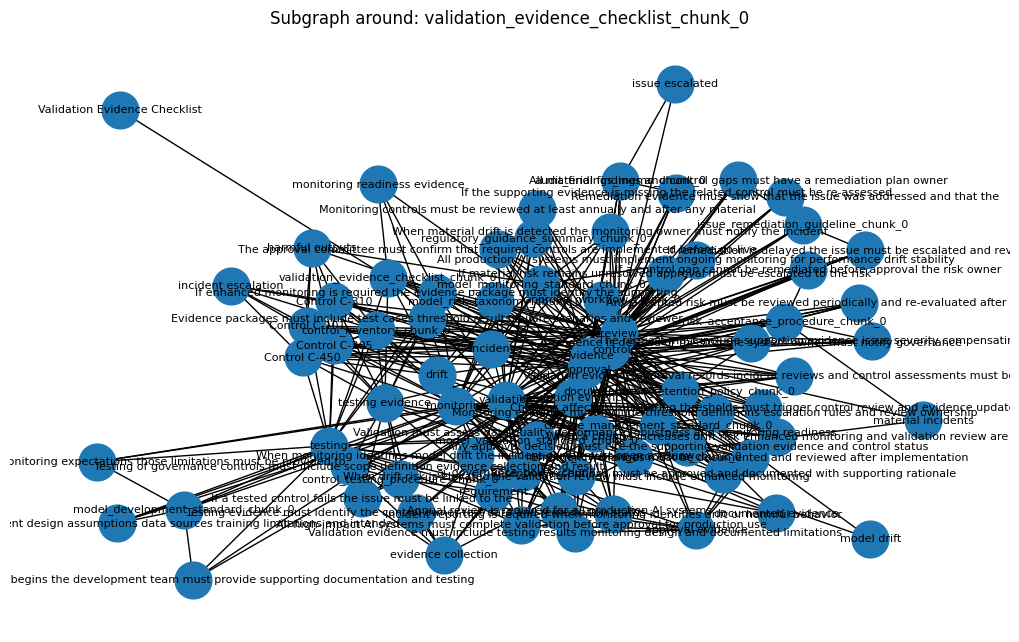

[DONE] Subgraph rendered and saved to C:\Users\minwuu01\GKN\artifacts\figures\subgraph_top_hybrid_20260613_135746.png


In [8]:
if hybrid_results:
    figure_path = artifacts.figures_dir / f'subgraph_top_hybrid_{run_id}.png'
    draw_subgraph(graph, hybrid_results[0].chunk_id, radius=2, save_path=figure_path)
    status(f'Subgraph rendered and saved to {figure_path}')
else:
    print('No hybrid results available to visualize.')

## 9. Run the benchmark query set

Evaluate baseline and hybrid retrieval over the benchmark set and save query-level plus aggregate reports.

In [9]:
test_cases = load_query_test_cases(config.eval_queries_path)
status(f'Loaded {len(test_cases)} evaluation queries from {config.eval_queries_path}.')

evaluation_rows = []
for case in test_cases:
    baseline_case_results = vector_store.search(case.query, top_k=config.top_k)
    hybrid_case_results = hybrid.search(case.query, top_k=config.top_k, graph_hops=config.graph_hops)

    baseline_metrics = evaluate_retrieval(baseline_case_results, case.relevant_chunk_ids)
    hybrid_metrics = evaluate_retrieval(hybrid_case_results, case.relevant_chunk_ids)

    print('\n' + '=' * 100)
    print(f'Query: {case.query}')
    print(f'Category: {case.category}')
    print(f'Baseline metrics: {baseline_metrics}')
    print(f'Hybrid metrics:   {hybrid_metrics}')

    evaluation_rows.append({
        'query': case.query,
        'category': case.category,
        'retriever': 'baseline',
        **baseline_metrics,
    })
    evaluation_rows.append({
        'query': case.query,
        'category': case.category,
        'retriever': 'hybrid',
        **hybrid_metrics,
    })

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)
evaluation_csv_path = artifacts.save_dataframe(evaluation_df, f'evaluation_query_level_{run_id}.csv')
evaluation_json_path = artifacts.save_json(evaluation_rows, f'evaluation_query_level_{run_id}.json', subdir='reports')
status(f'Saved query-level evaluation CSV to {evaluation_csv_path}')
status(f'Saved query-level evaluation JSON to {evaluation_json_path}')

aggregate_df = evaluation_df.groupby('retriever')[['hit_rate', 'recall_at_k', 'precision_at_k', 'mrr']].mean().reset_index()
display(aggregate_df)
aggregate_csv_path = artifacts.save_dataframe(aggregate_df, f'evaluation_aggregate_{run_id}.csv')
aggregate_json_path = artifacts.save_json(aggregate_df.to_dict(orient='records'), f'evaluation_aggregate_{run_id}.json', subdir='reports')
status(f'Saved aggregate evaluation CSV to {aggregate_csv_path}')
status(f'Saved aggregate evaluation JSON to {aggregate_json_path}')

[DONE] Loaded 8 evaluation queries from C:\Users\minwuu01\GKN\data\eval_queries.json.

Query: What evidence is required for validation approval?
Category: evidence_traceability
Baseline metrics: {'hit_rate': 1.0, 'recall_at_k': 0.75, 'precision_at_k': 1.0, 'mrr': 1.0}
Hybrid metrics:   {'hit_rate': 1.0, 'recall_at_k': 0.75, 'precision_at_k': 1.0, 'mrr': 1.0}

Query: Which control requires annual review of production AI systems?
Category: requirement_control_mapping
Baseline metrics: {'hit_rate': 1.0, 'recall_at_k': 0.6666666666666666, 'precision_at_k': 0.6666666666666666, 'mrr': 1.0}
Hybrid metrics:   {'hit_rate': 1.0, 'recall_at_k': 0.6666666666666666, 'precision_at_k': 0.6666666666666666, 'mrr': 1.0}

Query: What happens when monitoring identifies drift?
Category: multi_hop_incident
Baseline metrics: {'hit_rate': 1.0, 'recall_at_k': 0.75, 'precision_at_k': 1.0, 'mrr': 1.0}
Hybrid metrics:   {'hit_rate': 1.0, 'recall_at_k': 0.75, 'precision_at_k': 1.0, 'mrr': 1.0}

Query: Which contro

,query,category,retriever,hit_rate,recall_at_k,precision_at_k,mrr
0,What evidence is required for validation appro...,evidence_traceability,baseline,1.0,0.750000,1.000000,1.0
1,What evidence is required for validation appro...,evidence_traceability,hybrid,1.0,0.750000,1.000000,1.0
2,Which control requires annual review of produc...,requirement_control_mapping,baseline,1.0,0.666667,0.666667,1.0
3,Which control requires annual review of produc...,requirement_control_mapping,hybrid,1.0,0.666667,0.666667,1.0
4,What happens when monitoring identifies drift?,multi_hop_incident,baseline,1.0,0.750000,1.000000,1.0
5,What happens when monitoring identifies drift?,multi_hop_incident,hybrid,1.0,0.750000,1.000000,1.0
6,Which control supports monitoring for harmful ...,control_lookup,baseline,1.0,1.000000,0.666667,1.0
7,Which control supports monitoring for harmful ...,control_lookup,hybrid,1.0,1.000000,0.666667,1.0
8,What is required when a material model change ...,change_impact,baseline,1.0,1.000000,1.000000,1.0
9,What is required when a material model change ...,change_impact,hybrid,1.0,1.000000,1.000000,1.0


[DONE] Saved query-level evaluation CSV to C:\Users\minwuu01\GKN\artifacts\reports\evaluation_query_level_20260613_135746.csv
[DONE] Saved query-level evaluation JSON to C:\Users\minwuu01\GKN\artifacts\reports\evaluation_query_level_20260613_135746.json


,retriever,hit_rate,recall_at_k,precision_at_k,mrr
0,baseline,1.0,0.729167,0.75,1.000
1,hybrid,1.0,0.729167,0.75,0.875


[DONE] Saved aggregate evaluation CSV to C:\Users\minwuu01\GKN\artifacts\reports\evaluation_aggregate_20260613_135746.csv
[DONE] Saved aggregate evaluation JSON to C:\Users\minwuu01\GKN\artifacts\reports\evaluation_aggregate_20260613_135746.json


## 10. Save a run summary

Generate a short summary text file for this notebook run so the output package is easy to review later.

In [10]:
summary_text = '\n'.join([
    f'Run ID: {run_id}',
    f'Documents loaded: {len(documents)}',
    f'Chunks created: {len(chunks)}',
    f'Graph nodes: {graph.number_of_nodes()}',
    f'Graph edges: {graph.number_of_edges()}',
    f'Main query: {query}',
    f'Artifacts directory: {config.artifacts_dir}',
])
summary_path = artifacts.save_text(summary_text, f'run_summary_{run_id}.txt')
status(f'Saved run summary to {summary_path}')
print('\n' + summary_text)

[DONE] Saved run summary to C:\Users\minwuu01\GKN\artifacts\reports\run_summary_20260613_135746.txt

Run ID: 20260613_135746
Documents loaded: 16
Chunks created: 16
Graph nodes: 95
Graph edges: 456
Main query: What evidence is required for validation approval?
Artifacts directory: C:\Users\minwuu01\GKN\artifacts


## 11. Final note

This notebook now produces a saved evaluation package that can be reviewed outside the notebook through files in the local `artifacts/` directory.